# InsightFace Trial — RetinaFace Detection + ArcFace Embeddings

This notebook prototypes a face embeddings pipeline using the **InsightFace** framework:
- **RetinaFace** — detects faces and predicts 5 facial landmarks
- **ArcFace (R50)** — produces a 512-dimensional face embedding for recognition

Both are bundled in the `buffalo_l` model pack, downloaded automatically on first run.

## 1. Install Dependencies

In [18]:
# Use onnxruntime-gpu instead if you have a CUDA-capable GPU
!pip install insightface onnxruntime opencv-python-headless matplotlib pillow numpy

## 2. Imports

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.linalg import norm

import insightface
from insightface.app import FaceAnalysis
from insightface.utils import face_align

## 3. Initialize FaceAnalysis App

The `buffalo_l` pack bundles RetinaFace (detector) + ArcFace R50 (recognizer).  
Models (~400 MB total) are auto-downloaded to `~/.insightface/models/buffalo_l/` on first call.  
Set `ctx_id=-1` to force CPU-only execution.

In [20]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))  # ctx_id=0 GPU:0; change to -1 for CPU
print("Models loaded:", [m.taskname for m in app.models.values()])

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Models loade

## 4. Image Helpers

In [21]:
def load_bgr(path: str) -> np.ndarray:
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return img

def show(img, title: str = ""):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    plt.figure(figsize=(8, 6))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 5. Detect Faces in a Single Image

Replace `"sample.jpg"` with a path to any image containing one or more faces.

In [22]:
IMAGE_PATH = "img/times_square.jpg"

img = load_bgr(IMAGE_PATH)
faces = app.get(img)

print(f"Detected {len(faces)} face(s) (before quality filter)")
for i, f in enumerate(faces):
    x1, y1, x2, y2 = f.bbox.astype(int)
    print(f"  [{i}] det_score={f.det_score:.3f}  size={x2-x1}x{y2-y1}px  bbox={[x1,y1,x2,y2]}")

Detected 6 face(s) (before quality filter)
  [0] det_score=0.908  size=48x70px  bbox=[np.int64(399), np.int64(283), np.int64(447), np.int64(353)]
  [1] det_score=0.907  size=55x59px  bbox=[np.int64(86), np.int64(315), np.int64(141), np.int64(374)]
  [2] det_score=0.902  size=47x58px  bbox=[np.int64(313), np.int64(281), np.int64(360), np.int64(339)]
  [3] det_score=0.901  size=57x65px  bbox=[np.int64(509), np.int64(306), np.int64(566), np.int64(371)]
  [4] det_score=0.818  size=43x50px  bbox=[np.int64(217), np.int64(281), np.int64(260), np.int64(331)]
  [5] det_score=0.538  size=11x14px  bbox=[np.int64(39), np.int64(280), np.int64(50), np.int64(294)]


## 5b. Quality Filter — Reject Blurred / Low-Confidence Faces

Two independent checks run on every detected face:

| Check | Signal | Threshold |
|---|---|---|
| **Detection confidence** | `det_score` from RetinaFace | > 0.60 |
| **Sharpness (Laplacian variance)** | Variance of the Laplacian on the 112x112 aligned crop | > 50.0 |

A face must pass **both** checks. `faces` is reassigned so all downstream cells use the filtered list.

In [23]:
MIN_DET_SCORE = 0.60   # RetinaFace confidence gate
MIN_SHARPNESS = 50.0   # Laplacian variance gate — lower = blurrier

def face_sharpness(face, src_img: np.ndarray) -> float:
    """Laplacian variance of the 112x112 ArcFace-aligned crop."""
    crop = face_align.norm_crop(src_img, landmark=face.kps)
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def quality_check(face, src_img: np.ndarray):
    """Returns (passed: bool, reason: str)."""
    if face.det_score < MIN_DET_SCORE:
        return False, f"det_score {face.det_score:.3f} < {MIN_DET_SCORE}"
    sharpness = face_sharpness(face, src_img)
    if sharpness < MIN_SHARPNESS:
        return False, f"sharpness {sharpness:.1f} < {MIN_SHARPNESS}"
    return True, f"det={face.det_score:.3f}  sharp={sharpness:.1f}"


clear_faces, rejected = [], []
for i, f in enumerate(faces):
    passed, reason = quality_check(f, img)
    tag = "PASS" if passed else "SKIP"
    print(f"  [{i}] {tag} — {reason}")
    (clear_faces if passed else rejected).append(f)

faces = clear_faces
print(f"\n{len(faces)} face(s) passed  |  {len(rejected)} rejected")

  [0] PASS — det=0.908  sharp=102.9
  [1] PASS — det=0.907  sharp=166.3
  [2] PASS — det=0.902  sharp=107.2
  [3] PASS — det=0.901  sharp=192.9
  [4] PASS — det=0.818  sharp=56.7
  [5] SKIP — det_score 0.538 < 0.6

5 face(s) passed  |  1 rejected


## 6. Visualize — Bounding Boxes & 5-Point Landmarks (RetinaFace)

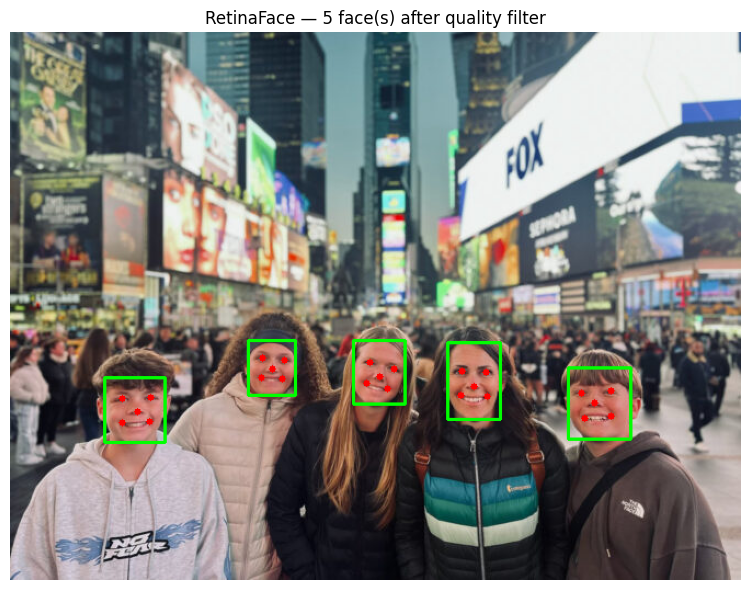

In [24]:
vis = img.copy()
for f in faces:
    x1, y1, x2, y2 = f.bbox.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for kp in f.kps.astype(int):
        cv2.circle(vis, tuple(kp), 3, (0, 0, 255), -1)

show(vis, f"RetinaFace — {len(faces)} face(s) after quality filter")

## 7. Extract ArcFace Embedding (512-d vector)

The embedding is L2-normalized so that cosine similarity equals the dot product.

In [25]:
raw_emb = faces[0].embedding                  # (512,) float32 computed by app.get()
emb_norm = raw_emb / norm(raw_emb)            # L2-normalize

print(f"Embedding shape : {raw_emb.shape}")
print(f"L2 norm (raw)   : {norm(raw_emb):.4f}")
print(f"L2 norm (after) : {norm(emb_norm):.6f}")  # should be exactly 1.0
print(f"First 8 values  : {emb_norm[:8].round(4)}")

Embedding shape : (512,)
L2 norm (raw)   : 23.1641
L2 norm (after) : 1.000000
First 8 values  : [ 0.0313  0.0258 -0.0095  0.0401 -0.0379  0.009   0.0923 -0.0596]


## 8. Face Verification — Cosine Similarity Between Two Images

Typical thresholds (ArcFace R50, `buffalo_l`):
- **> 0.50** likely the **same** person
- **< 0.30** likely **different** people
- 0.30-0.50 uncertain zone

In [26]:
def get_embedding(path: str) -> np.ndarray:
    detected = app.get(load_bgr(path))
    if not detected:
        raise ValueError(f"No face detected in: {path}")
    e = detected[0].embedding
    return e / norm(e)

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b))  # valid because both are L2-normalized


PERSON_A_1 = "img/person_a_1.jpg"
PERSON_A_2 = "img/person_a_2.jpg"
PERSON_B   = "img/person_b.jpg"

e_a1 = get_embedding(PERSON_A_1)
e_a2 = get_embedding(PERSON_A_2)
e_b  = get_embedding(PERSON_B)

print(f"Same person  (A1 vs A2): {cosine_sim(e_a1, e_a2):.4f}  expect > 0.50")
print(f"Diff person  (A1 vs B) : {cosine_sim(e_a1, e_b):.4f}  expect < 0.30")

Same person  (A1 vs A2): 0.7616  expect > 0.50
Diff person  (A1 vs B) : 0.0324  expect < 0.30


## 9. Simple In-Memory Face Registry (1:N Identification)

In [27]:
registry = {}  # name -> L2-normalized embedding

def register(name: str, path: str):
    registry[name] = get_embedding(path)
    print(f"Registered {name} from {path}")

def identify(path: str, threshold: float = 0.45):
    query = get_embedding(path)
    scores = {name: cosine_sim(query, emb) for name, emb in registry.items()}
    best_name = max(scores, key=scores.get)
    best_score = scores[best_name]
    if best_score >= threshold:
        return best_name, best_score
    return "Unknown", best_score


# Example usage (replace with real paths)
# register("Alice", "alice.jpg")
# register("Bob",   "bob.jpg")
# result = identify("test.jpg")
# print(f"Identified as: {result[0]}  (score={result[1]:.4f})")

## 10. Multi-Face Image — Extract All Embeddings

In [28]:
GROUP_IMAGE = "img/times_square.jpg"

group_img = load_bgr(GROUP_IMAGE)
all_detected = app.get(group_img)

group_faces = [f for f in all_detected if quality_check(f, group_img)[0]]

embeddings = [f.embedding / norm(f.embedding) for f in group_faces]

print(f"Detected {len(all_detected)} face(s), {len(group_faces)} passed quality filter")
print(f"Embedding matrix shape: {np.array(embeddings).shape}")

Detected 6 face(s), 5 passed quality filter
Embedding matrix shape: (5, 512)


## 11. Aligned Face Crops (112x112)

`face_align.norm_crop` applies an affine transform using the 5 landmarks so eyes, nose,
and mouth land in fixed canonical positions — the exact input format ArcFace was trained on.

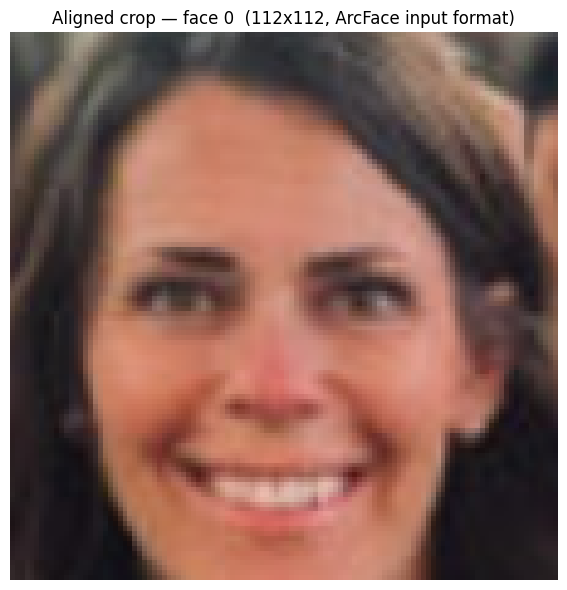

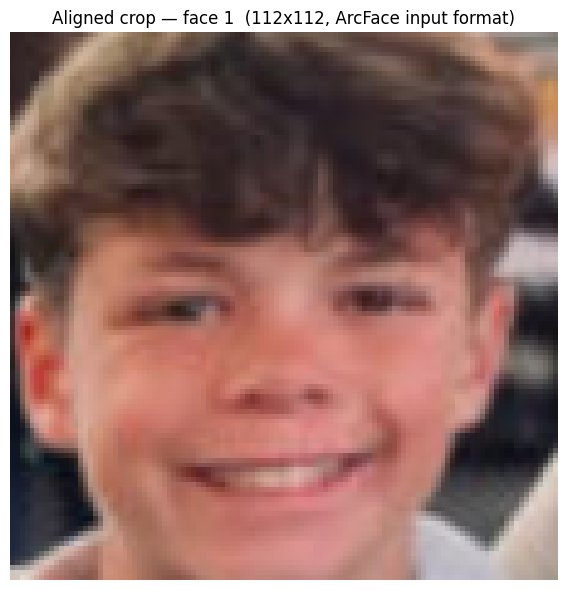

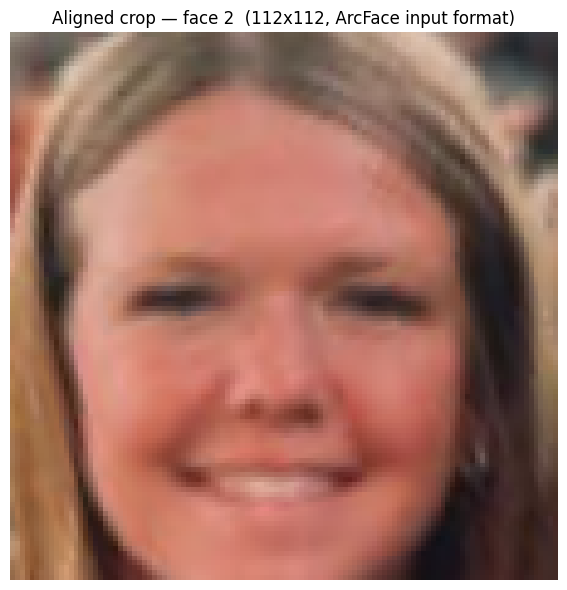

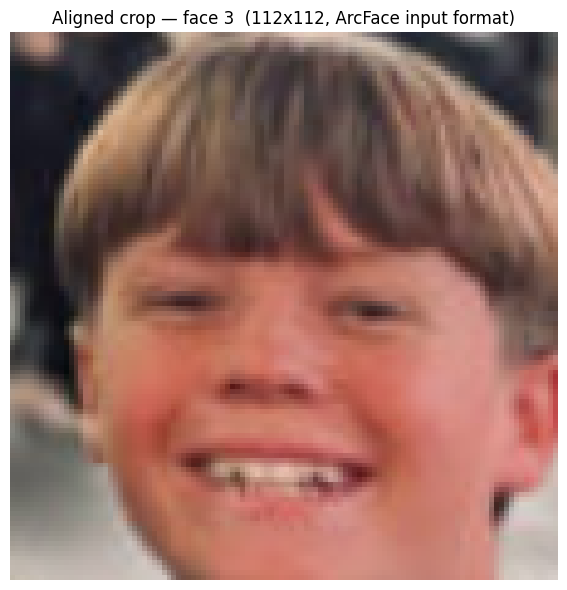

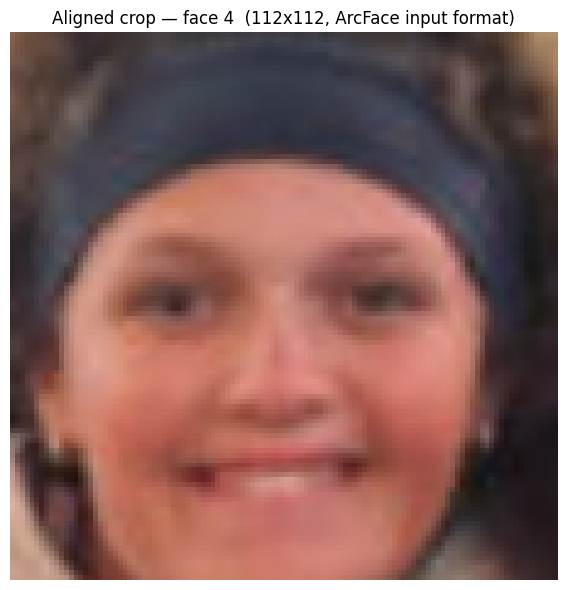

In [29]:
for i, face in enumerate(faces):
    aligned = face_align.norm_crop(img, landmark=face.kps)  # 112x112 BGR
    show(aligned, f"Aligned crop — face {i}  (112x112, ArcFace input format)")